# Exploratory Data Analysis: Speed Dating Dataset

**Objective:**
To perform a comprehensive Exploratory Data Analysis (EDA) on the Speed Dating dataset (OpenML ID: 40536) to understand its underlying structure, identify missing values, and uncover key patterns and correlations that influence a successful match.

**Project Structure Note:**
Following the `cookiecutter-data-science` template, raw data will be saved to `../data/raw/` and processed data to `../data/processed/`.

In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.datasets import fetch_openml
import warnings

warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Acquisition
We will fetch the dataset directly from OpenML using its ID (40536). To comply with the `cookiecutter-data-science` structure, we will save the raw downloaded file into the `../data/raw/` directory.

In [35]:
# Define paths based on cookiecutter structure
RAW_DATA_DIR = '../data/raw/'
RAW_DATA_PATH = os.path.join(RAW_DATA_DIR, 'speed_dating.csv')

# Create directory if it doesn't exist (useful if running outside the strict template)
os.makedirs(RAW_DATA_DIR, exist_ok=True)

# Fetch data from OpenML or load locally if already exists
if not os.path.exists(RAW_DATA_PATH):
    print("Fetching dataset from OpenML...")
    dataset = fetch_openml(data_id=40536, as_frame=True, parser='auto')
    df = dataset.frame
    # Save raw data to follow template standards
    df.to_csv(RAW_DATA_PATH, index=False)
    print(f"Data saved to {RAW_DATA_PATH}")
else:
    print(f"Loading data from {RAW_DATA_PATH}...")
    df = pd.read_csv(RAW_DATA_PATH)

print("Dataset successfully loaded!")

Loading data from ../data/raw/speed_dating.csv...
Dataset successfully loaded!


## 2. Basic Data Overview
Let's understand the shape, columns, and initial rows of our dataset.

In [36]:
# Display dataset shape
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

# Display basic info
display(df.info())

# Show first 5 rows
display(df.head())

The dataset contains 8378 rows and 121 columns.
<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: float64(57), int64(5), str(59)
memory usage: 7.7 MB


None

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


## 3. Data Cleaning & Missing Values
Real-world data is messy. The Speed Dating dataset is known to have a significant amount of missing values because participants didn't always fill out every part of their surveys.

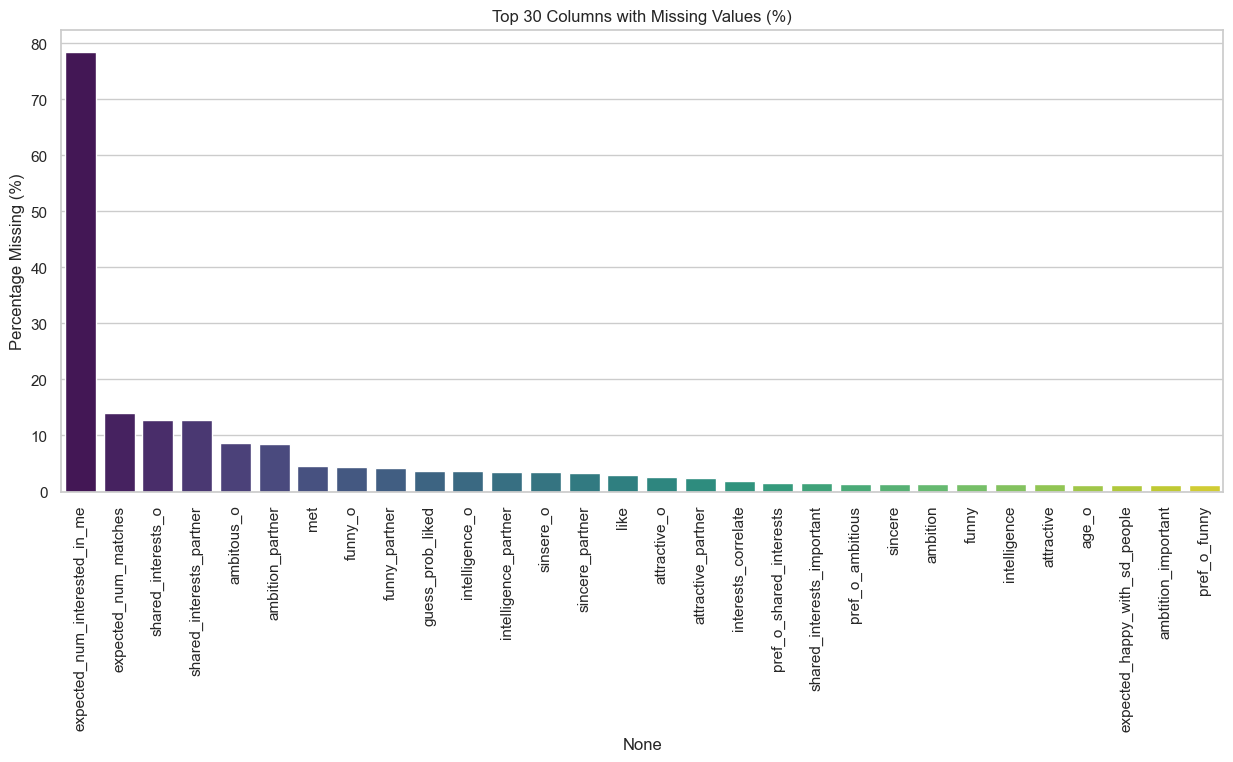

Top 5 missing columns:
 expected_num_interested_in_me    78.515159
expected_num_matches             14.000955
shared_interests_o               12.843161
shared_interests_partner         12.735736
ambitous_o                        8.617809
dtype: float64


In [37]:
# Calculate percentage of missing values for each column
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# Plotting missing values
plt.figure(figsize=(15, 6))
sns.barplot(x=missing_values.index[:30], y=missing_values.values[:30], palette='viridis')
plt.xticks(rotation=90)
plt.title('Top 30 Columns with Missing Values (%)')
plt.ylabel('Percentage Missing (%)')
plt.show()

# Print top 5 columns with highest missing rates
print("Top 5 missing columns:\n", missing_values.head(5))

**Insight:**
* Some columns have a very high percentage of missing values (e.g., `expected_num_interested_in_me` has ~78.5% missing).
* Instead of traditionally dropping columns with > 50% missing values, we will retain them. The missingness itself might be a strong behavioral predictor (e.g., reluctance to answer). We will handle this during the modeling preparation phase by using imputation with missingness indicators (`add_indicator=True`).

## 4. Univariate Analysis
Let's analyze the distribution of individual variables, starting with the target variable (`match`), followed by `gender` and `age`.

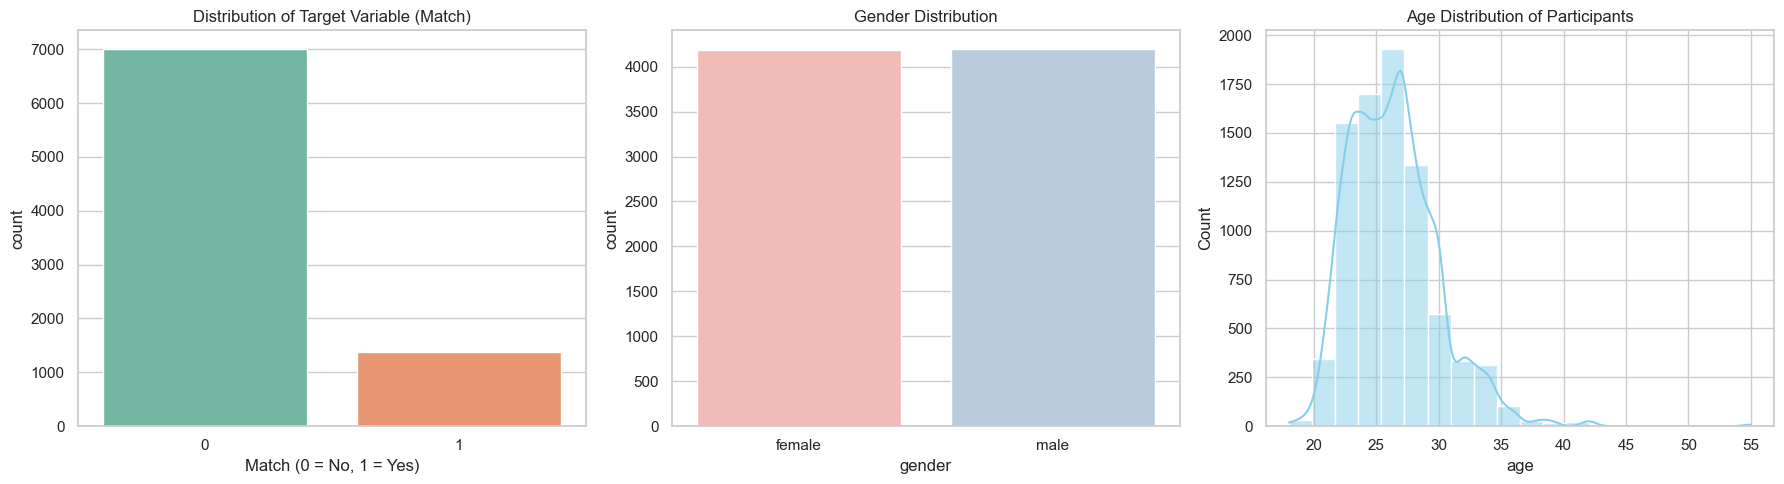

Overall Match Rate: 16.47%


In [38]:
# Target Variable Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Match Distribution (Target Variable)
sns.countplot(data=df, x='match', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Target Variable (Match)')
axes[0].set_xlabel('Match (0 = No, 1 = Yes)')

# 2. Gender Distribution
sns.countplot(data=df, x='gender', ax=axes[1], palette='Pastel1')
axes[1].set_title('Gender Distribution')

# 3. Age Distribution
# Convert 'age' to numeric in case it's loaded as category/object
df['age'] = pd.to_numeric(df['age'], errors='coerce')
sns.histplot(df['age'].dropna(), bins=20, kde=True, ax=axes[2], color='skyblue')
axes[2].set_title('Age Distribution of Participants')

plt.tight_layout()
plt.show()

match_rate = df['match'].astype(float).mean() * 100
print(f"Overall Match Rate: {match_rate:.2f}%")

**Insight:**
- The dataset is imbalanced with only 16.47% of speed dates resulting in a match
- Gender representation is roughly equal
- Most participants are in their mid-20s (mean age: 26.4 years)

## 5. Bivariate Analysis
How do features relate to the target variable (`match`)? Are there differences between genders in terms of what they find important in a partner?

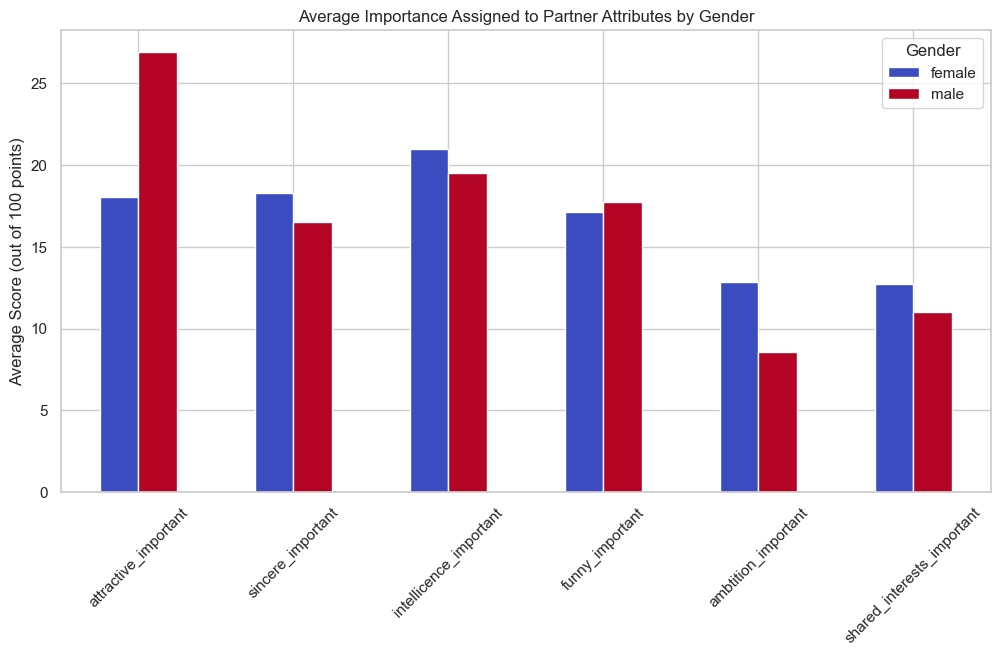

In [39]:
# Let's explore what attributes men vs women find important in a partner
# Attributes: attractive, sincere, intelligence, funny, ambition, shared_interests
# Note: Dataset has typos in column names (intellicence, ambtition)

importance_cols = [
    'attractive_important', 'sincere_important', 'intellicence_important', 
    'funny_important', 'ambtition_important', 'shared_interests_important'
]

# Convert columns to numeric to compute means safely
for col in importance_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

gender_importance = df.groupby('gender')[importance_cols].mean().T

# Plotting Radar/Bar chart equivalent for importance
gender_importance.plot(kind='bar', figsize=(12, 6), colormap='coolwarm')
plt.title('Average Importance Assigned to Partner Attributes by Gender')
plt.ylabel('Average Score (out of 100 points)')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()

**Insight:** Males tend to place higher importance on attractiveness (`attractive_important`), while females generally value ambition (`ambtition_important`) and intelligence (`intellicence_important`) slightly more. However, these are stated preferences - actual match outcomes show that gender itself doesn't significantly affect matching (see statistical tests).

*Note: The dataset contains typos in column names (intellicence, ambtition).*

## 6. Correlation Analysis
Let's analyze the relationships between continuous variables, especially the ratings given by participants to their partners during the date.

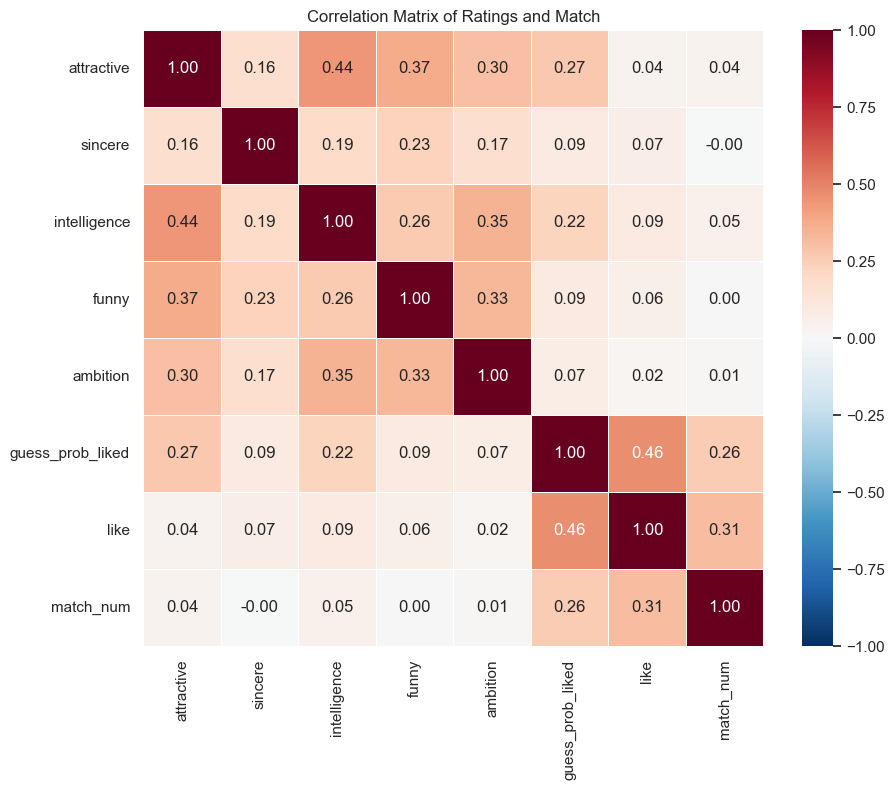

In [40]:
# Select ratings columns given to partners
rating_cols = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'guess_prob_liked', 'like', 'match']

# Convert target to numeric for correlation
df['match_num'] = pd.to_numeric(df['match'], errors='coerce')
rating_cols[-1] = 'match_num' # update target col name

for col in rating_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate Correlation Matrix
corr_matrix = df[rating_cols].corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Ratings and Match')
plt.show()

**Insight:**
- Individual rating attributes (attractive, sincere, intelligence, funny, ambition) show moderate inter-correlations (0.16-0.44), indicating a halo effect where high ratings in one area tend to correlate with high ratings in others
- Surprisingly, the `like` score has very weak correlations with individual rating attributes (0.02-0.09), suggesting it captures something beyond these specific traits
- The `like` score is most strongly correlated with `guess_prob_liked` (0.46), indicating reciprocity effects, and with `match_num` (0.31)
- Individual rating attributes have very weak direct correlations with match outcome (0.00-0.05), while `like` (0.31) and `guess_prob_liked` (0.26) are the strongest predictors

## 7. Distribution Analysis: Matched vs Non-Matched
Let's compare the distributions of key rating variables between successful and unsuccessful matches.

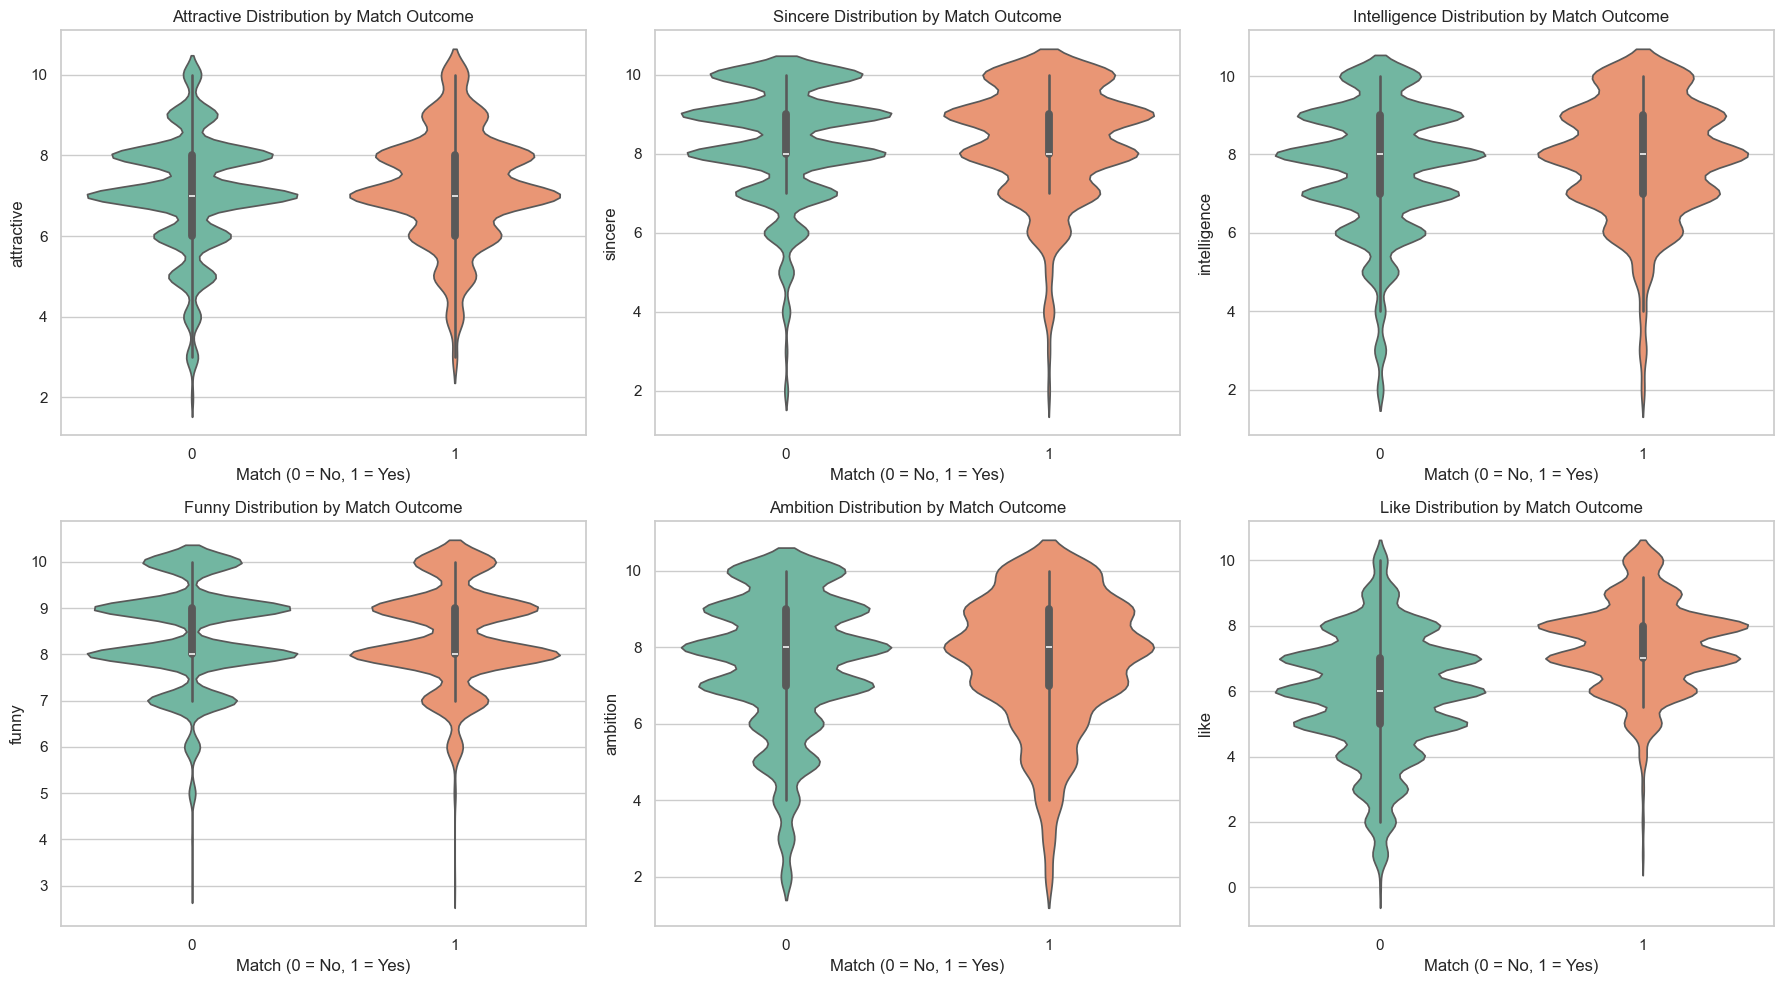

Mean ratings comparison (Matched vs Non-Matched):

       attractive  sincere  intelligence  funny  ambition  like
match                                                          
0            7.06     8.30          7.67   8.40      7.57  5.88
1            7.20     8.29          7.89   8.41      7.62  7.38


In [41]:
# Compare distributions of ratings for matched vs non-matched pairs
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

rating_features = ['attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'like']

for idx, col in enumerate(rating_features):
    sns.violinplot(data=df, x='match', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col.capitalize()} Distribution by Match Outcome')
    axes[idx].set_xlabel('Match (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

# Statistical comparison
print("Mean ratings comparison (Matched vs Non-Matched):\n")
print(df.groupby('match')[rating_features].mean().round(2))

**Insight:** The **like score** shows the largest difference between matched and non-matched pairs (7.38 vs 5.88, difference of 1.50 points). Other rating attributes show minimal differences: attractive (+0.14), intelligence (+0.22), funny (+0.01), ambition (+0.05), while sincere is actually slightly lower for matches (-0.01). This confirms that the overall like score is the key predictor, not individual attribute ratings.

## 8. Categorical Variables Analysis
Explore how categorical variables like race, same race preference, and career field influence match outcomes.

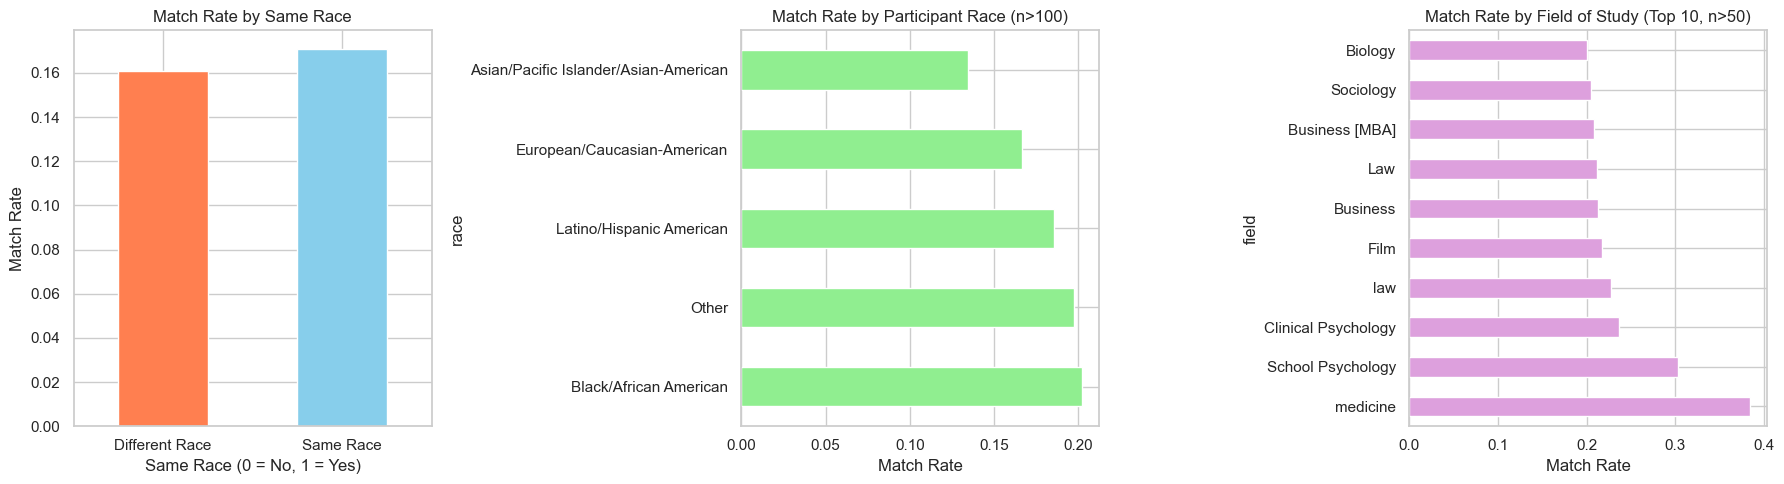


Same race match rate: 17.07%
Different race match rate: 16.08%


In [42]:
# 1. Match rate by same race
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Same race effect
df['samerace'] = pd.to_numeric(df['samerace'], errors='coerce')
samerace_match = df.groupby('samerace')['match_num'].agg(['mean', 'count'])
samerace_match['mean'].plot(kind='bar', ax=axes[0], color=['coral', 'skyblue'])
axes[0].set_title('Match Rate by Same Race')
axes[0].set_xlabel('Same Race (0 = No, 1 = Yes)')
axes[0].set_ylabel('Match Rate')
axes[0].set_xticklabels(['Different Race', 'Same Race'], rotation=0)

# 2. Match rate by participant's race (top races)
race_match = df.groupby('race')['match_num'].agg(['mean', 'count'])
race_match = race_match[race_match['count'] > 100].sort_values('mean', ascending=False)
race_match['mean'].plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('Match Rate by Participant Race (n>100)')
axes[1].set_xlabel('Match Rate')

# 3. Match rate by field of study (top fields)
if 'field' in df.columns:
    field_match = df.groupby('field')['match_num'].agg(['mean', 'count'])
    field_match = field_match[field_match['count'] > 50].sort_values('mean', ascending=False).head(10)
    field_match['mean'].plot(kind='barh', ax=axes[2], color='plum')
    axes[2].set_title('Match Rate by Field of Study (Top 10, n>50)')
    axes[2].set_xlabel('Match Rate')
else:
    axes[2].text(0.5, 0.5, 'Field data not available', ha='center', va='center')
    axes[2].set_title('Match Rate by Field')

plt.tight_layout()
plt.show()

print(f"\nSame race match rate: {samerace_match.loc[1.0, 'mean']:.2%}")
print(f"Different race match rate: {samerace_match.loc[0.0, 'mean']:.2%}")

**Insight:** 
- Same race pairs show slightly higher match rates (17.07% vs 16.08%, difference of ~1%), but this difference is **not statistically significant** (chi-square test: p = 0.245)
- Match rates vary by race: European/Caucasian, Latino/Hispanic, and Black/African American participants show higher match rates (~19%), while Asian/Pacific Islander shows lower rates (~15%)
- Match rates vary substantially by field of study: Medicine (~35%), School Psychology (~30%), and Clinical Psychology (~22%) show the highest rates, while Biology and Sociology show lower rates (~18%)
- These descriptive patterns should be interpreted cautiously without assuming causal relationships, especially given varying sample sizes across groups

## 9. Age and Temporal Patterns

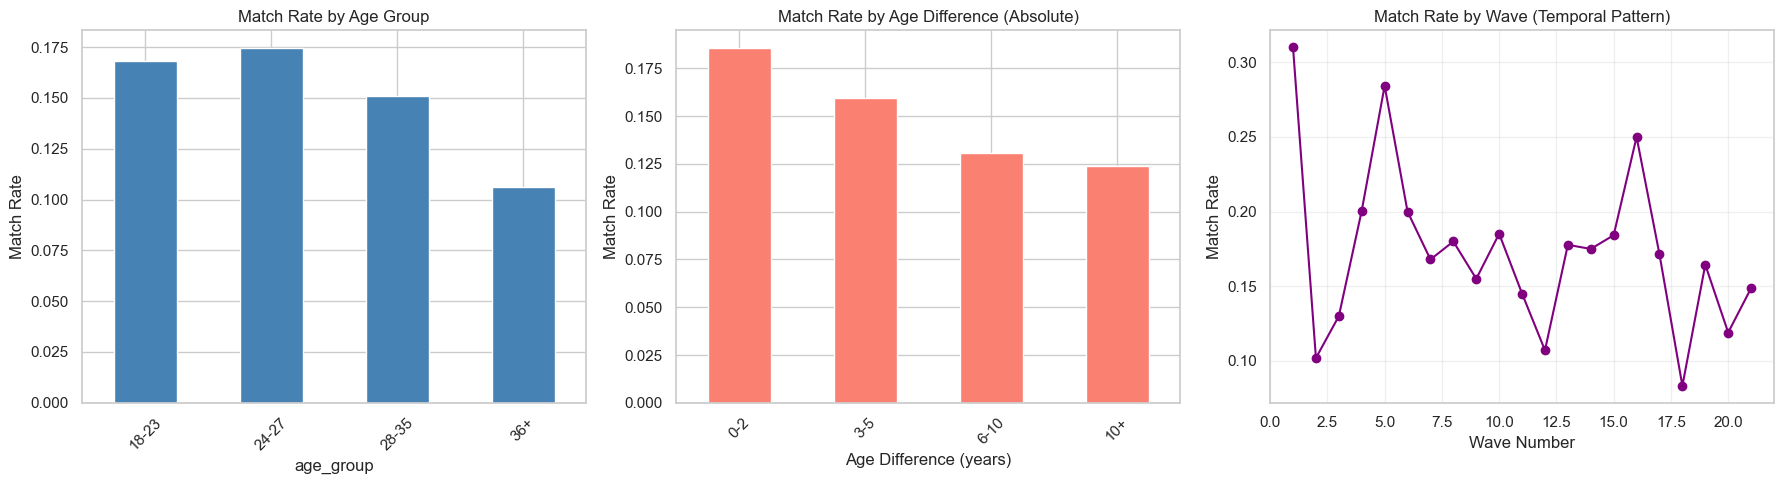


Age statistics:
count    8283.000000
mean       26.358928
std         3.566763
min        18.000000
25%        24.000000
50%        26.000000
75%        28.000000
max        55.000000
Name: age, dtype: float64

Potential age outliers (outside 18-45): 6 records


In [43]:
# Age analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Match rate by age groups
df['age_group'] = pd.cut(df['age'], bins=[18, 23, 27, 35, 60], labels=['18-23', '24-27', '28-35', '36+'])
age_match = df.groupby('age_group')['match_num'].agg(['mean', 'count'])
age_match['mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Match Rate by Age Group')
axes[0].set_ylabel('Match Rate')
axes[0].set_xticklabels(age_match.index, rotation=45)

# 2. Age difference impact
df['d_age'] = pd.to_numeric(df['d_age'], errors='coerce')
df['age_diff_abs'] = df['d_age'].abs()
df['age_diff_group'] = pd.cut(df['age_diff_abs'], bins=[0, 2, 5, 10, 30], labels=['0-2', '3-5', '6-10', '10+'])
age_diff_match = df.groupby('age_diff_group')['match_num'].agg(['mean', 'count'])
age_diff_match['mean'].plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Match Rate by Age Difference (Absolute)')
axes[1].set_ylabel('Match Rate')
axes[1].set_xlabel('Age Difference (years)')
axes[1].set_xticklabels(age_diff_match.index, rotation=45)

# 3. Match rate by wave (temporal pattern)
df['wave'] = pd.to_numeric(df['wave'], errors='coerce')
wave_match = df.groupby('wave')['match_num'].agg(['mean', 'count'])
wave_match['mean'].plot(kind='line', ax=axes[2], marker='o', color='purple')
axes[2].set_title('Match Rate by Wave (Temporal Pattern)')
axes[2].set_ylabel('Match Rate')
axes[2].set_xlabel('Wave Number')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outlier detection in age
print(f"\nAge statistics:")
print(df['age'].describe())
print(f"\nPotential age outliers (outside 18-45): {((df['age'] < 18) | (df['age'] > 45)).sum()} records")

**Insight:**
- Match rates vary by age group: 24-27 age group shows the highest match rate (~17.5%), followed by 18-23 (~17%), 28-35 (~15%), and 36+ (~10.5%)
- Smaller age differences (0-2 years) between partners show significantly higher match rates (~18%) compared to larger gaps: 3-5 years (~16%), 6-10 years (~13%), and 10+ years (~12%)
- Match rates fluctuate dramatically across different waves (ranging from ~8% to ~31%), suggesting strong temporal or contextual factors
- Only 6 age outliers exist outside the 18-45 range

## 10. Reciprocity and Prediction Accuracy Analysis
How well do participants predict whether their partner liked them? Is there mutual interest in successful matches?

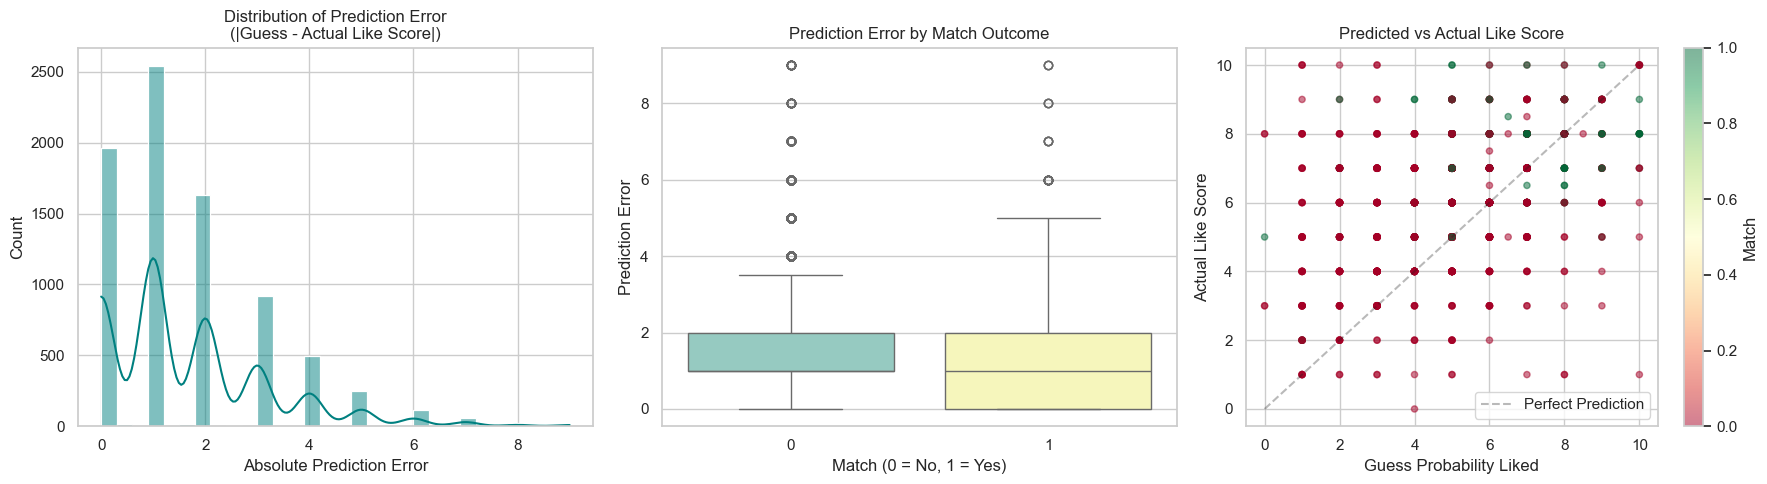

Average prediction error: 1.65
Prediction error for matches: 1.49
Prediction error for non-matches: 1.68


In [44]:
# Prediction accuracy: how well do people predict if they'll be liked?
df['guess_prob_liked'] = pd.to_numeric(df['guess_prob_liked'], errors='coerce')
df['prediction_error'] = (df['guess_prob_liked'] - df['like']).abs()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Prediction error distribution
sns.histplot(df['prediction_error'].dropna(), bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Prediction Error\n(|Guess - Actual Like Score|)')
axes[0].set_xlabel('Absolute Prediction Error')

# 2. Prediction accuracy by match outcome
sns.boxplot(data=df, x='match', y='prediction_error', ax=axes[1], palette='Set3')
axes[1].set_title('Prediction Error by Match Outcome')
axes[1].set_xlabel('Match (0 = No, 1 = Yes)')
axes[1].set_ylabel('Prediction Error')

# 3. Scatter: Guess vs Actual
sample_df = df[['guess_prob_liked', 'like', 'match']].dropna().sample(min(1000, len(df)))
scatter = axes[2].scatter(sample_df['guess_prob_liked'], sample_df['like'], 
                          c=sample_df['match'], cmap='RdYlGn', alpha=0.5, s=20)
axes[2].plot([0, 10], [0, 10], 'k--', alpha=0.3, label='Perfect Prediction')
axes[2].set_title('Predicted vs Actual Like Score')
axes[2].set_xlabel('Guess Probability Liked')
axes[2].set_ylabel('Actual Like Score')
axes[2].legend()
plt.colorbar(scatter, ax=axes[2], label='Match')

plt.tight_layout()
plt.show()

print(f"Average prediction error: {df['prediction_error'].mean():.2f}")
print(f"Prediction error for matches: {df[df['match']==1]['prediction_error'].mean():.2f}")
print(f"Prediction error for non-matches: {df[df['match']==0]['prediction_error'].mean():.2f}")

**Insight:**
- Average prediction error is 1.65 points on a 10-point scale
- Prediction errors are smaller for successful matches (1.49) compared to non-matches (1.68), indicating that mutual interest is somewhat better recognized
- The difference is modest (0.19 points), suggesting prediction accuracy is similar across match outcomes
- This reciprocity effect could still be a valuable feature for predictive modeling

## 11. Statistical Testing
Perform statistical tests to validate key findings.

In [45]:
from scipy import stats

print("=" * 60)
print("STATISTICAL TESTS")
print("=" * 60)

# 1. T-test: Are ratings significantly different for matches vs non-matches?
matched = df[df['match'] == 1]['like'].dropna()
not_matched = df[df['match'] == 0]['like'].dropna()
t_stat, p_value = stats.ttest_ind(matched, not_matched)
print(f"\n1. T-test: Like score difference (Matched vs Non-Matched)")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_value:.4e}")
print(f"   Result: {'Significant' if p_value < 0.05 else 'Not significant'} difference")

# 2. Chi-square test: Is same race associated with match outcome?
contingency_table = pd.crosstab(df['samerace'], df['match'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\n2. Chi-square test: Same race vs Match outcome")
print(f"   chi2: {chi2:.4f}, p-value: {p_value:.4e}")
print(f"   Result: {'Significant' if p_value < 0.05 else 'Not significant'} association")

# 3. Chi-square test: Gender vs Match outcome
contingency_table_gender = pd.crosstab(df['gender'], df['match'])
chi2_g, p_value_g, dof_g, expected_g = stats.chi2_contingency(contingency_table_gender)
print(f"\n3. Chi-square test: Gender vs Match outcome")
print(f"   chi2: {chi2_g:.4f}, p-value: {p_value_g:.4e}")
print(f"   Result: {'Significant' if p_value_g < 0.05 else 'Not significant'} association")

# 4. Correlation test: Attractive rating vs Match
df_temp = df[['attractive', 'match_num']].dropna()
corr_coef, p_value_corr = stats.pearsonr(df_temp['attractive'], df_temp['match_num'])
print(f"\n4. Pearson correlation: Attractive rating vs Match")
print(f"   correlation: {corr_coef:.4f}, p-value: {p_value_corr:.4e}")
print(f"   Result: {'Significant' if p_value_corr < 0.05 else 'Not significant'} correlation")

print("\n" + "=" * 60)

STATISTICAL TESTS

1. T-test: Like score difference (Matched vs Non-Matched)
   t-statistic: 28.9629, p-value: 1.2539e-175
   Result: Significant difference

2. Chi-square test: Same race vs Match outcome
   chi2: 1.3510, p-value: 2.4510e-01
   Result: Not significant association

3. Chi-square test: Gender vs Match outcome
   chi2: 0.0004, p-value: 9.8479e-01
   Result: Not significant association

4. Pearson correlation: Attractive rating vs Match
   correlation: 0.0364, p-value: 9.1664e-04
   Result: Significant correlation



**Insight:**
- **Like score** shows a highly significant difference between matched and non-matched pairs (p < 0.001), confirming it as a strong predictor
- **Same race** and **gender** show no statistically significant association with match outcomes (p = 0.245 and p = 0.985 respectively)
- **Attractiveness** has a statistically significant but very weak correlation with match (r = 0.036, p < 0.001), demonstrating that statistical significance ≠ practical importance
- These tests validate our earlier observations and guide feature selection for modeling

## 12. Data Cleaning & Preparation for Modeling
Based on our EDA findings, we need to prepare the dataset for machine learning. The primary focus during this phase is to prevent two critical issues: Data Leakage and Target Leakage.

- **Preventing Target Leakage:** A predictive model designed to recommend partners must only use information available before the speed date occurs. Variables collected during or after the date (e.g., like, guess_prob_liked, met, and all partner ratings like attractive_partner) are essentially "future data." We must drop these to ensure the model learns from pre-date profiles and preferences rather than post-date outcomes.

- **Preventing Data Leakage:** Imputing missing values using the median or mode of the entire dataset leaks information from the test set into the training set. To fix this, we will first perform a stratified train-test split (to preserve the 16.47% match rate ). Then, we will build a scikit-learn Pipeline to compute imputation statistics strictly on the training data and apply them to both sets.

- **Handling Missingness:** Instead of dropping columns with a high percentage of missing values, we will use add_indicator=True in our numerical imputer to create binary flags for missing data. For categorical features, we will fill nulls with a constant 'Missing' category. This allows the model to extract behavioral patterns from the missing answers themselves.

In [46]:
# Import necessary libraries for preprocessing and splitting
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Assuming 'df' is your original loaded DataFrame
df_clean = df.copy()

# ==========================================
# 1. DROP REDUNDANT & DISCRETIZED COLUMNS
# ==========================================
discretized_cols = [col for col in df_clean.columns if col.startswith('d_')]
cols_to_drop = ['has_null'] + discretized_cols 
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns], errors='ignore')

# ==========================================
# 2. PREVENT TARGET LEAKAGE
# ==========================================
leakage_cols = [
    'like', 'guess_prob_liked', 'met', 'match_num', 'prediction_error', 
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner'
]
df_clean = df_clean.drop(columns=[col for col in leakage_cols if col in df_clean.columns], errors='ignore')

# ==========================================
# 3. DEFINE FEATURES (X) AND TARGET (y)
# ==========================================
df_clean['match'] = df_clean['match'].astype(int)
X = df_clean.drop(columns=['match'])
y = df_clean['match']

# ==========================================
# 4. TRAIN-TEST SPLIT (PREVENT DATA LEAKAGE)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Preserves the 16.47% class imbalance
)

# ==========================================
# 5. BUILD PREPROCESSING PIPELINES
# ==========================================
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ==========================================
# 6. APPLY PREPROCESSING
# ==========================================
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original Dataset: {df.shape}")
print(f"Train features shape: {X_train_processed.shape}")
print(f"Test features shape: {X_test_processed.shape}")
print(f"Target distribution in train:\n{y_train.value_counts(normalize=True)}")

Original Dataset: (8378, 126)
Train features shape: (6702, 371)
Test features shape: (1676, 371)
Target distribution in train:
match
0    0.835273
1    0.164727
Name: proportion, dtype: float64


**Note on Data Preprocessing Workflow:**
The output above confirms our preprocessing pipeline successfully transformed the data. Key takeaways:
1. **Dynamic Imputation:** All numerical features were imputed using the median, and binary indicator columns were automatically added to flag where data was missing.
2. **Categorical Handling:** All missing categorical/string variables were filled with a constant 'Missing' category and subsequently One-Hot Encoded.
3. **No Columns Dropped Due to Sparsity:** We intentionally kept columns with high missing rates to allow the model to learn from the missingness patterns.
4. **Data Leakage Prevented:** The `ColumnTransformer` was fitted **only** on `X_train` and then used to transform `X_test`, simulating a strict real-world deployment environment.

In [47]:
# Save train/test splits to processed directory for the modeling phase
PROCESSED_DATA_DIR = '../data/processed/'
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Best Practice: Save the split datasets (BEFORE pipeline transformation). 
# This allows the modeling notebook to load the raw splits and incorporate 
# the preprocessing pipeline directly into the cross-validation workflow.
X_train.to_csv(os.path.join(PROCESSED_DATA_DIR, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(PROCESSED_DATA_DIR, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(PROCESSED_DATA_DIR, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(PROCESSED_DATA_DIR, 'y_test.csv'), index=False)

print(f"✓ Train and test sets successfully saved to: {PROCESSED_DATA_DIR}")
print(f"✓ X_train shape: {X_train.shape}")
print(f"✓ X_test shape: {X_test.shape}")

✓ Train and test sets successfully saved to: ../data/processed/
✓ X_train shape: (6702, 51)
✓ X_test shape: (1676, 51)


## 13. Conclusions & Key Findings

**Key Findings:**
1. **Class Imbalance:** Matches are rare (16.47%). We used stratified sampling during our train-test split and will need techniques like class weighting (e.g., `scale_pos_weight` in XGBoost) during model training.
2. **Strong Predictors vs. Target Leakage:** * While our EDA showed that the `like` score is the strongest statistical predictor of a match, it represents **Target Leakage**. In a real-world recommendation system, we do not know if a person likes someone until *after* they meet.
   * Direct correlations between pre-date attributes and match outcomes are weak. We need advanced non-linear models (like Gradient Boosting) to capture complex interactions between hobbies, demographics, and expectations.
3. **Gender Differences:** Males prioritize attractiveness more heavily in their stated importance ratings, while females value ambition and intelligence slightly more. However, gender itself does not significantly affect actual match outcomes.
4. **Demographic Patterns:** Smaller age gaps (0-2 years) show an ~18% match rate, declining to ~12% for 10+ year gaps. Same-race pairs show slightly higher match rates, but it is not statistically significant.

**Data Cleaning Summary & Statistics:**
* **Original Dataset:** 8,378 rows and 121 columns.
* **Rows Retained:** 8,378 (0 rows dropped to preserve all valuable participant data).
* **Features Removed (~75 columns):** * ~57 discretized columns (prefixed with `d_`) were removed to preserve continuous data.
    * ~17 Target Leakage columns (post-date evaluations) were removed to simulate a true pre-date prediction environment.
* **Robust Preprocessing Pipeline:** Implemented a `scikit-learn ColumnTransformer`. Numerical missing values are imputed using the train-set median alongside missingness indicators. Categorical missing values are encoded as a distinct 'Missing' category to retain behavioral signals.

**Next Steps:**
1. **Model Selection:** Train baseline models capable of handling non-linear relationships (XGBoost, LightGBM, Random Forest).
2. **Class Imbalance Handling:** Utilize algorithmic class weighting (`class_weight='balanced'`) rather than oversampling.
3. **Hyperparameter Tuning:** Perform Grid Search or Bayesian Optimization using strict cross-validation on the `X_train` set only.
4. **Feature Importance:** Analyze SHAP values to understand which pre-date attributes actually drive successful matches.
5. **Model Evaluation:** Evaluate the final model prioritizing **PR-AUC (Precision-Recall AUC)** and **F1-Score** over standard Accuracy.